## K-Means Clustering on Iris Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Load dataset and display number of samples and features

In [2]:
iris = load_iris()
print("Samples:", iris.data.shape[0])
print("Features:", iris.data.shape[1])

Samples: 150
Features: 4


### Separate X and y

In [3]:
X = iris.data
y = iris.target

**Why is y not used in clustering?**

Clustering is unsupervised learning. It does not use labels.

### Feature scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Why is scaling necessary in K-Means?**

K-Means uses distance. Scaling makes all features equal.

### Apply K-Means (k=3)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
print("Cluster labels:")
print(kmeans.labels_)
print("\nCentroids:")
print(kmeans.cluster_centers_)

Cluster labels:
[1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]

Centroids:
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


### Plot Petal Length vs Petal Width

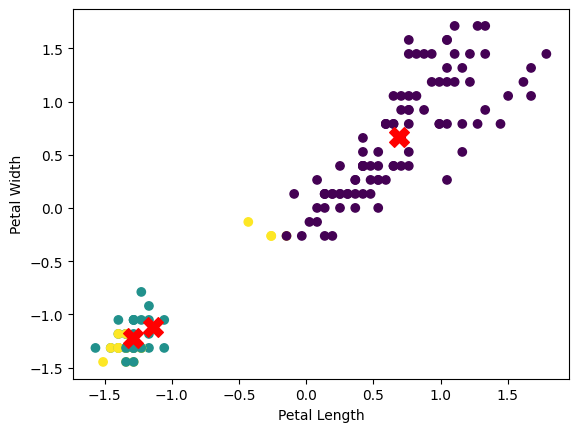

In [6]:
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], c='red', marker='X', s=200)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()

### Compute WCSS

In [7]:
print("WCSS:", kmeans.inertia_)

WCSS: 191.0247368531797


**What does WCSS represent?**

Sum of squared distances from each point to its cluster center. Lower is better.

### Elbow Method

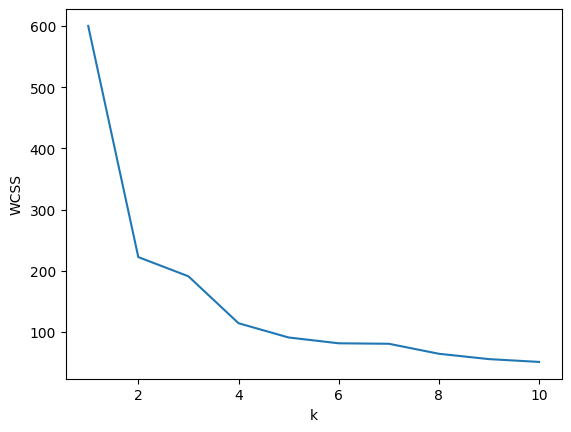

Optimal k: 3


In [8]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

print("Optimal k: 3")

### Compare clusters with actual species

In [9]:
print("Clusters:", kmeans.labels_)
print("Actual:", y)

Clusters: [1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


**Is the match perfect?**

No. K-Means groups by distance, not labels. Some overlap between species 1 and 2.

### K-Means with k=2

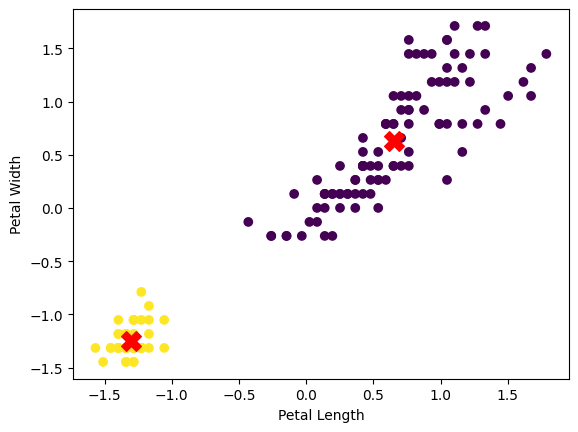

WCSS: 222.36170496502308


In [10]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
kmeans2.fit(X_scaled)
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=kmeans2.labels_)
plt.scatter(kmeans2.cluster_centers_[:, 2], kmeans2.cluster_centers_[:, 3], c='red', marker='X', s=200)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()
print("WCSS:", kmeans2.inertia_)

### K-Means with k=4

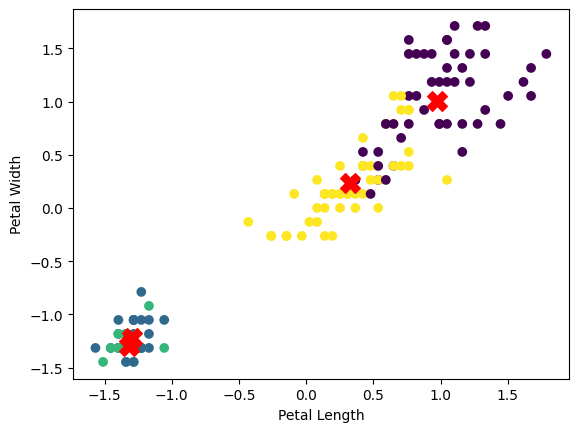

WCSS: 114.35407164049776


In [11]:
kmeans4 = KMeans(n_clusters=4, random_state=42)
kmeans4.fit(X_scaled)
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=kmeans4.labels_)
plt.scatter(kmeans4.cluster_centers_[:, 2], kmeans4.cluster_centers_[:, 3], c='red', marker='X', s=200)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()
print("WCSS:", kmeans4.inertia_)

**Observations:**

k=2: Two clusters formed. One species split from the other two.

k=4: Over-clustering. One species split into two clusters.

### Two limitations of K-Means

1. Must specify k beforehand
2. Sensitive to outliers